In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL

print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_bt_dem.csv")
data=data[(data['draws']>1)]
participantcode = data.participant.unique()

data["draws"] = data["draws"].astype(theano.config.floatX)

In [4]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_dtd=data["draws"].mean()
sd_dtd=data["draws"].std()

median_dtd=data["draws"].median()


In [5]:
hr_bt= pm.Model(coords=coords) 

with hr_bt:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=m_dtd, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", sd_dtd)
    mu_b = pm.Normal("mu_b", mu=0.0, sigma=0.5)
    sigma_b = pm.HalfNormal("sigma_b", 0.5)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)

    draws_est = a[participant_idx] + b[participant_idx] * data.session.values

    # Data likelihood
    draws_like = pm.Poisson(
        "draws_like", mu=draws_est, sigma=eps, observed=data.draws, dims="obs_id")
    
    

TypeError: __init__() got an unexpected keyword argument 'sigma'

In [ ]:
pm.model_to_graphviz(hr_bt)

In [30]:
with hr_bt:
    hr_bt_trace = pm.sample(5000,tune=5000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eps, b, a, sigma_b, mu_b, sigma_a, mu_a]


Sampling 2 chains for 5_000 tune and 5_000 draw iterations (10_000 + 10_000 draws total) took 235 seconds.
There were 963 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7436876042926142, but should be close to 0.9. Try to increase the number of tuning steps.
There were 893 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7689968307437274, but should be close to 0.9. Try to increase the number of tuning steps.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.


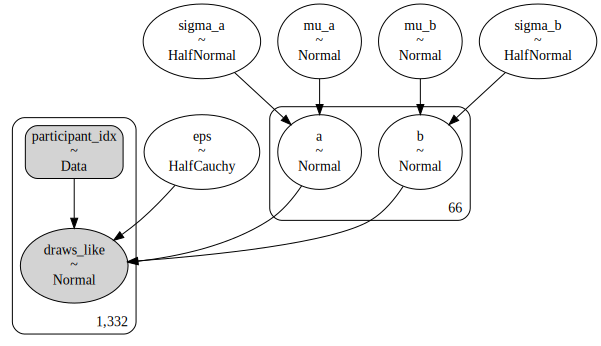

In [31]:
pm.model_to_graphviz(hr_bt)

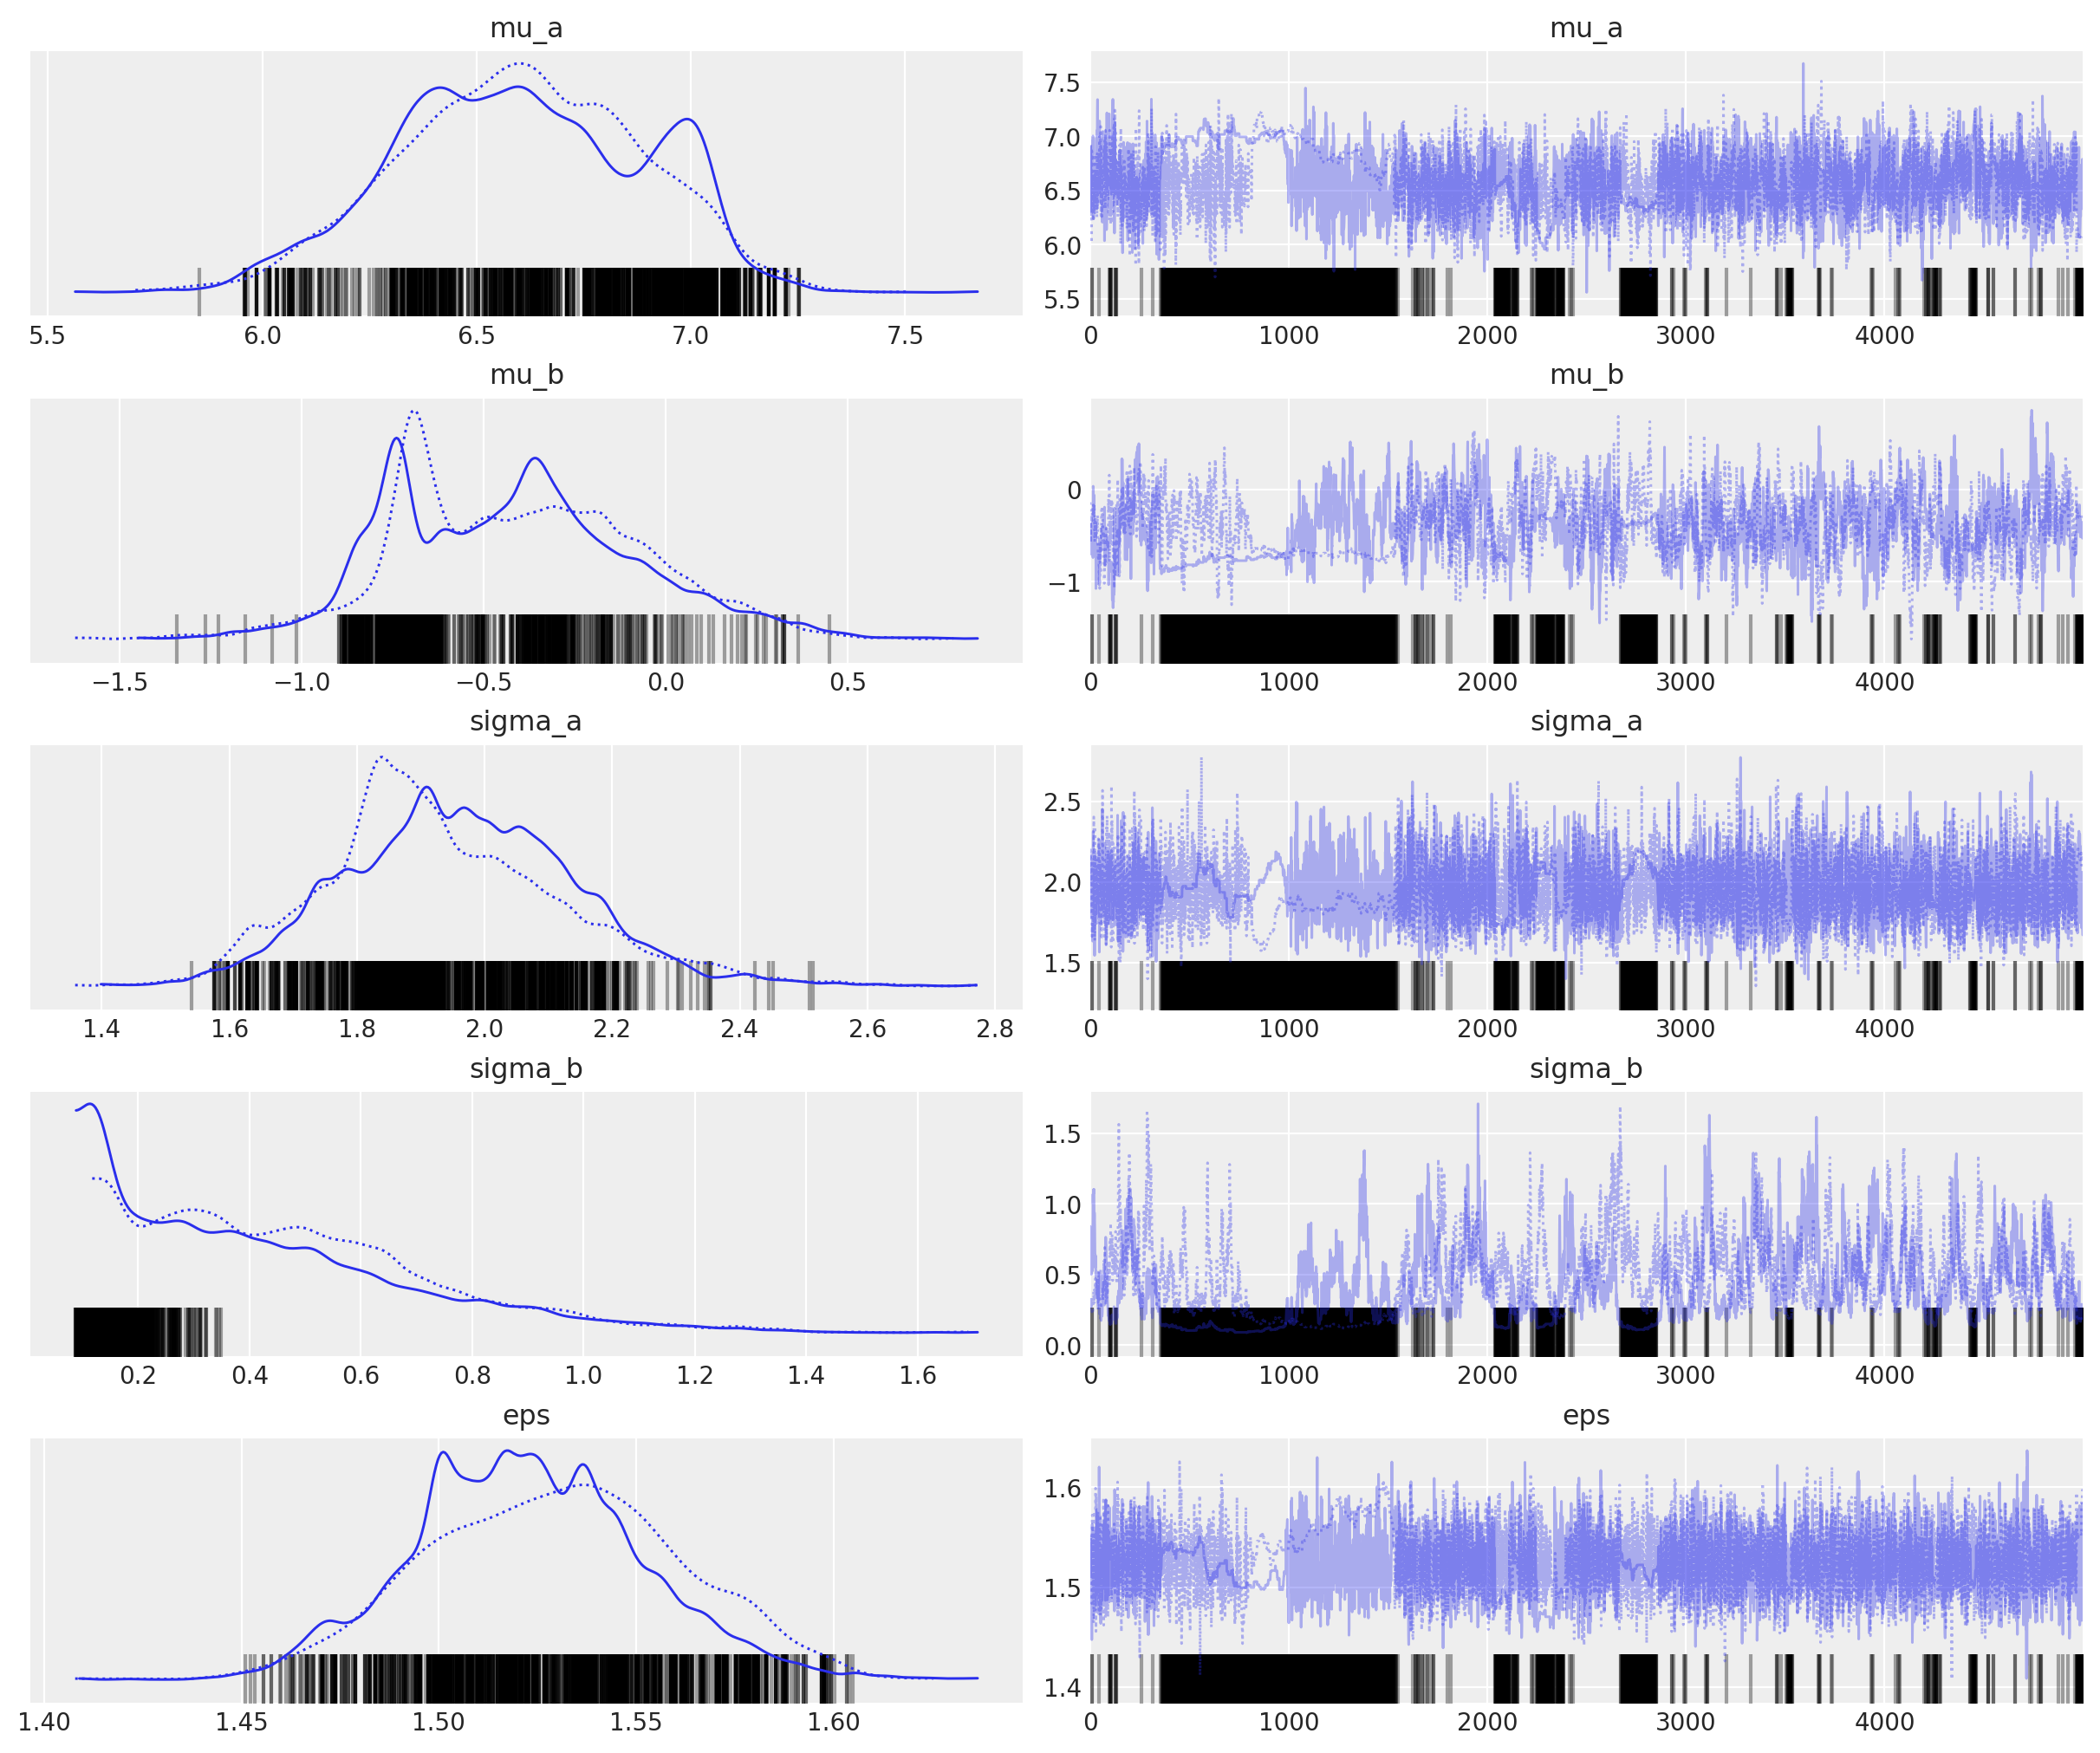

In [32]:
az.plot_trace(hr_bt_trace, var_names=["mu_a", "mu_b", "sigma_a", "sigma_b", "eps"]);


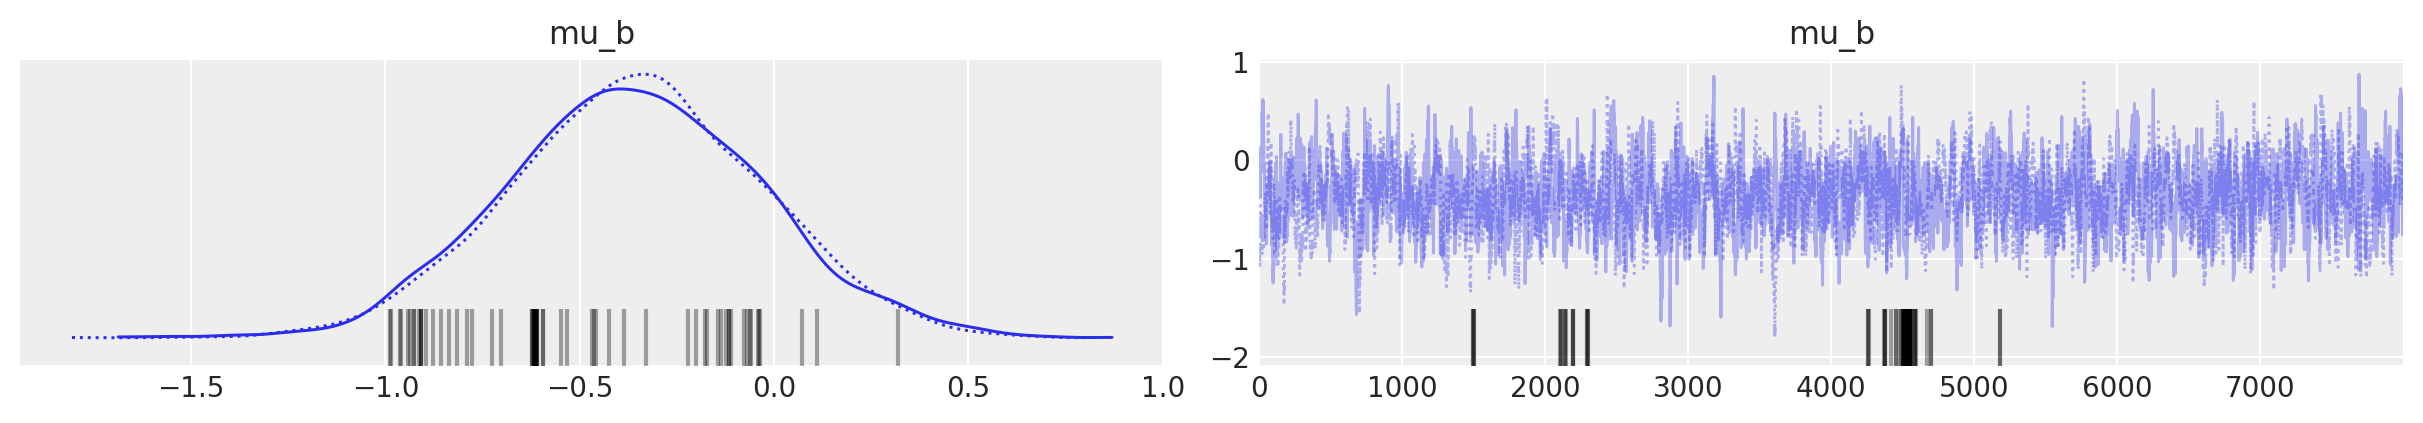

In [17]:
az.plot_trace(hr_bt_trace, var_names=["mu_b"]);


ValueError: not enough values to unpack (expected 2, got 1)

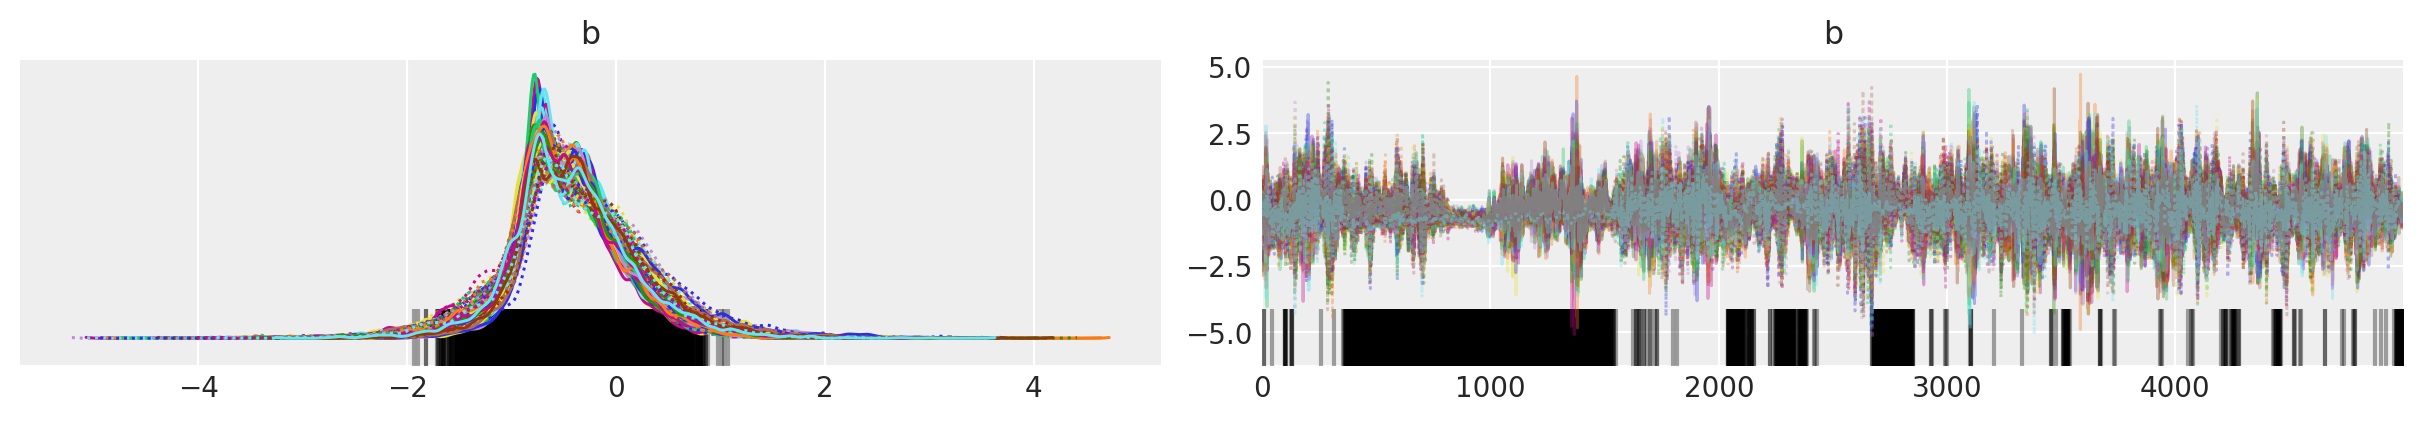

In [33]:
fig, b_trace_BT=az.plot_trace(hr_bt_trace, var_names=["b"], coords={"participant": participant});
b_trace_BT.save("b_trace_BT.jpg")

In [34]:
stat_tms_reg=pm.summary(hr_bt_trace)
stat_tms_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.601,0.282,6.100,7.102,0.034,0.025,69.0,287.0,1.01
mu_b,-0.414,0.334,-0.963,0.255,0.032,0.023,107.0,1211.0,1.01
a[AD20],4.915,0.655,3.654,6.153,0.021,0.015,883.0,2370.0,1.01
a[AF12],8.386,0.646,7.119,9.505,0.047,0.033,178.0,1953.0,1.01
a[AR05],6.413,0.678,5.162,7.704,0.044,0.031,223.0,358.0,1.00
...,...,...,...,...,...,...,...,...,...
b[WO04],-0.306,0.592,-1.354,0.867,0.038,0.027,202.0,1802.0,1.01
b[ZZ99],-0.417,0.614,-1.565,0.812,0.030,0.021,308.0,1962.0,1.01
sigma_a,1.947,0.183,1.611,2.291,0.007,0.005,682.0,842.0,1.01
sigma_b,0.441,0.268,0.089,0.924,0.037,0.026,33.0,38.0,1.08


In [35]:
b_mu_reg=stat_tms_reg.loc['mu_b']['mean']
b_sigma_reg=stat_tms_reg.loc['mu_b']['sd']

In [36]:

print ("OVL Beta TMS vs O") 
b_tms=NormalDist(mu=b_mu_reg, sigma=b_sigma_reg).overlap(NormalDist(mu=0, sigma=0.05))
print (b_tms)

OVL Beta TMS vs O
0.1480741307811282


In [12]:
dtd_1=trace_groups.get_values(varname="mu", chains=1)
dtd_1=pd.DataFrame(dtd_1)

NameError: name 'trace_groups' is not defined

In [32]:
with hr_bt:
    ppc_reg = pm.sample_posterior_predictive(
        hr_bt_trace, var_names=["a", "b","draws_like"]
    )

<AxesSubplot:xlabel='draws_like / draws_like'>

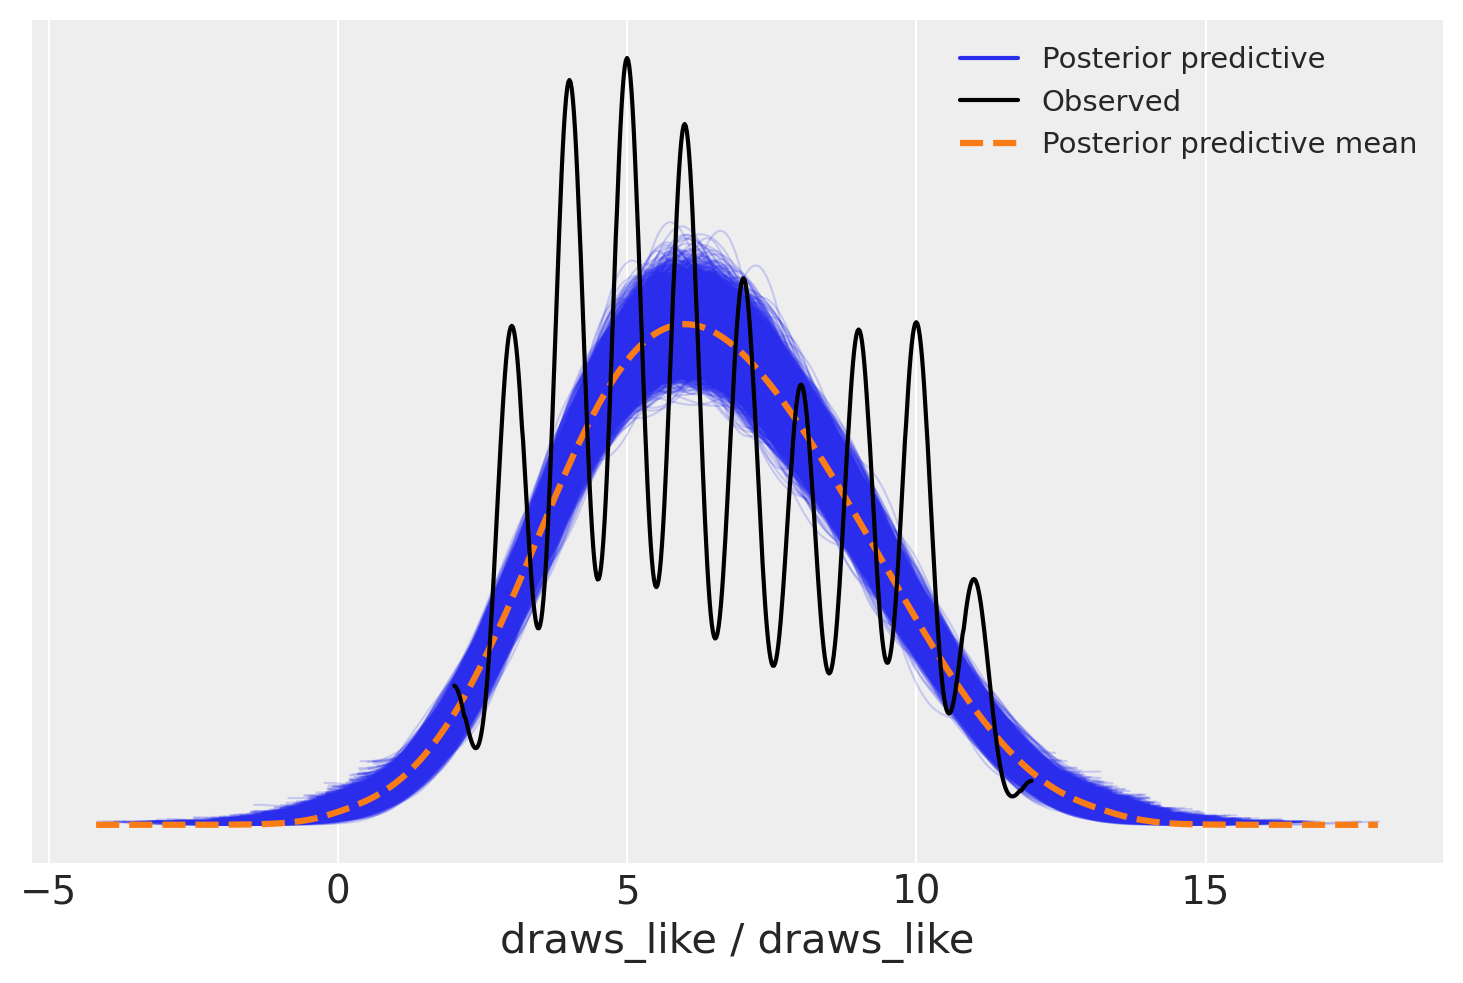

In [33]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_bt))